In [3]:
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score
from matplotlib import pyplot as plt
import pandas as pd

In [20]:
y_pred = np.array([0.1, 0.4, 0.35, 0.8, 0.9, 0.7])
y_test = np.array([0, 0, 1, 1, 1, 0])
n_bootstraps = 4
rng_seed = 42  # control reproducibility
indices = np.random.randint(0, len(y_pred), (len(y_pred), n_bootstraps))
y_test[indices]

array([[0, 0, 1, 0],
       [0, 1, 0, 0],
       [1, 1, 1, 0],
       [0, 0, 0, 1],
       [1, 1, 1, 0],
       [0, 1, 1, 0]])

In [21]:
bootstrapped_AUCs = []
bootstrapped_AUprcs = []

rng = np.random.RandomState(rng_seed)
for i in range(n_bootstraps):
    # bootstrap by sampling with replacement on the prediction indices
    ind = indices[:, i]

    score = roc_auc_score(y_test[ind],y_pred[ind])
    bootstrapped_AUCs.append(score)
    score = average_precision_score(y_test[ind],y_pred[ind])
    bootstrapped_AUprcs.append(score)

bootstrapped_AUCs, bootstrapped_AUprcs

([0.5, 0.875, 0.75, 1.0], [0.5, 0.95, 0.9166666666666666, 1.0])

In [24]:
bootstrapped_auprcs = average_precision_score(y_test[indices], y_pred[indices], average=None)
bootstrapped_aucs = roc_auc_score(y_test[indices], y_pred[indices], average=None)
bootstrapped_aucs, bootstrapped_auprcs

(array([0.5  , 0.875, 0.75 , 1.   ]),
 array([0.5       , 0.95      , 0.91666667, 1.        ]))

In [21]:
N = 100000
y_test = np.random.randint(0, 2, N)
y_pred0 = np.random.normal(0.2, 0.1, N)
y_pred1 = np.random.normal(0.3, 0.1, N)
y_pred = np.where(y_test == 0, y_pred0, y_pred1)

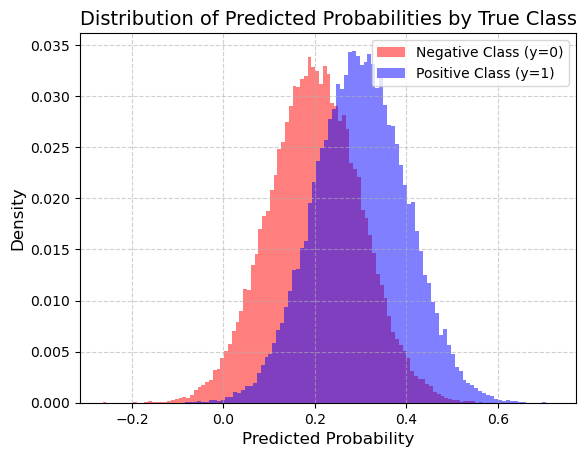

In [25]:
    # Probability densities of predicted probabilities
    prob_class0 = y_pred[y_test == 0]
    prob_class1 = y_pred[y_test == 1]
    # plt.figure(figsize=(8, 5))
    plt.hist(prob_class0, bins=100, alpha=0.5, weights=np.ones(len(prob_class0)) / len(prob_class0), color='red', label='Negative Class (y=0)')
    plt.hist(prob_class1, bins=100, alpha=0.5, weights=np.ones(len(prob_class1)) / len(prob_class1), color='blue', label='Positive Class (y=1)')
    plt.xlabel('Predicted Probability', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.title('Distribution of Predicted Probabilities by True Class', fontsize=14)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

In [5]:
s = pd.Series([3, 1, 4, 2, 5])
s.cummax()

0    3
1    3
2    4
3    4
4    5
dtype: int64